In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [43]:
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        errors.append(np.linalg.norm(x_new - x, ord=np.inf))
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k+1, errors
        x = x_new
    return x, max_iterations, errors

In [44]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        # Check for convergence
        errors.append(np.linalg.norm(x_new - x, ord=np.inf))
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k+1, errors
        x = x_new
    return x, max_iterations, errors


In [67]:
A = np.array([[3.0, -0.1, -0.2], [0.1, 7, -0.3], [0.3, -0.2, 10]])
B = np.array([7.85, -19.3, 71.4])
x = np.zeros_like(B)

In [68]:
sol3j, iterations3j, error3j = jacobi(A, B, x, 0.001, 100)
sol6j, iterations6j, error6j = jacobi(A, B, x, 0.000001, 100)
sol9j, iterations9j, error9j = jacobi(A, B, x, 0.000000001, 100)

In [69]:
sol3g, iterations3g, error3g = gauss_seidel(A, B, x, 0.001, 100)
sol6g, iterations6g, error6g = gauss_seidel(A, B, x, 0.000001, 100)
sol9g, iterations9g, error9g = gauss_seidel(A, B, x, 0.000000001, 100)

In [70]:
print("Tolerance: 1*10^-3")
print("iterations for jacobi:", iterations3j, "\niterations for gauss_seidel:", iterations3g)
print("Tolerance: 1*10^-6")
print("iterations for jacobi:", iterations6j, "\niterations for gauss_seidel:", iterations6g)
print("Tolerance: 1*10^-9")
print("iterations for jacobi:", iterations9j, "\niterations for gauss_seidel:", iterations9g)

Tolerance: 1*10^-3
iterations for jacobi: 4 
iterations for gauss_seidel: 4
Tolerance: 1*10^-6
iterations for jacobi: 7 
iterations for gauss_seidel: 5
Tolerance: 1*10^-9
iterations for jacobi: 9 
iterations for gauss_seidel: 7


Plot:

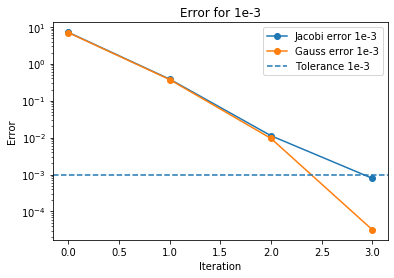

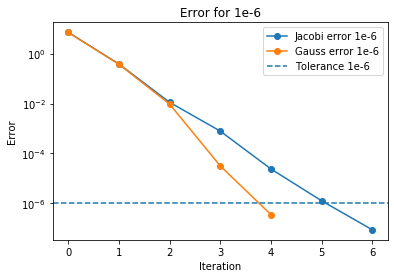

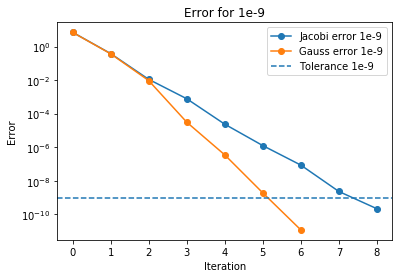

In [83]:
plt.plot(error3j, marker = 'o', label='Jacobi error 1e-3')
plt.plot(error3g, marker = 'o', label='Gauss error 1e-3')
plt.yscale("log")
plt.axhline(1e-3, linestyle='--', label="Tolerance 1e-3")
plt.title("Error for 1e-3")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.legend()
plt.show()

plt.plot(error6j, marker = 'o', label='Jacobi error 1e-6')
plt.plot(error6g, marker = 'o', label='Gauss error 1e-6')
plt.yscale("log")
plt.axhline(1e-6, linestyle='--', label="Tolerance 1e-6")
plt.title("Error for 1e-6")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.legend()
plt.show()

plt.plot(error9j, marker = 'o', label='Jacobi error 1e-9')
plt.plot(error9g, marker = 'o', label='Gauss error 1e-9')
plt.yscale("log")
plt.axhline(1e-9, linestyle='--', label="Tolerance 1e-9")
plt.title("Error for 1e-9")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.legend()
plt.show()

Conclusion: the Gauss method always converges below the tolerance level first between Jacobi and Gauss. As the tolerance became lower, both methods had to go through more iterations to decrease the error below the tolerance, as seen with my print satements. And taking info from the in class challenge, I would assume decreasing the tolerance would increase runtime.

Source: ChatGpt helped me find out how to make the graphs look more informative since having an exponential decay funciton was hard to see. It told me to use the line "plt.yscale("log")" and the line "plt.axhline(1e-9, linestyle='--', label="Tolerance 1e-9")" to scale the y axis and show the tolerance level